# Bài tập thực hành tuần 2
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Sáng thứ 6)

### Bài tập 1:
**Câu hỏi**:

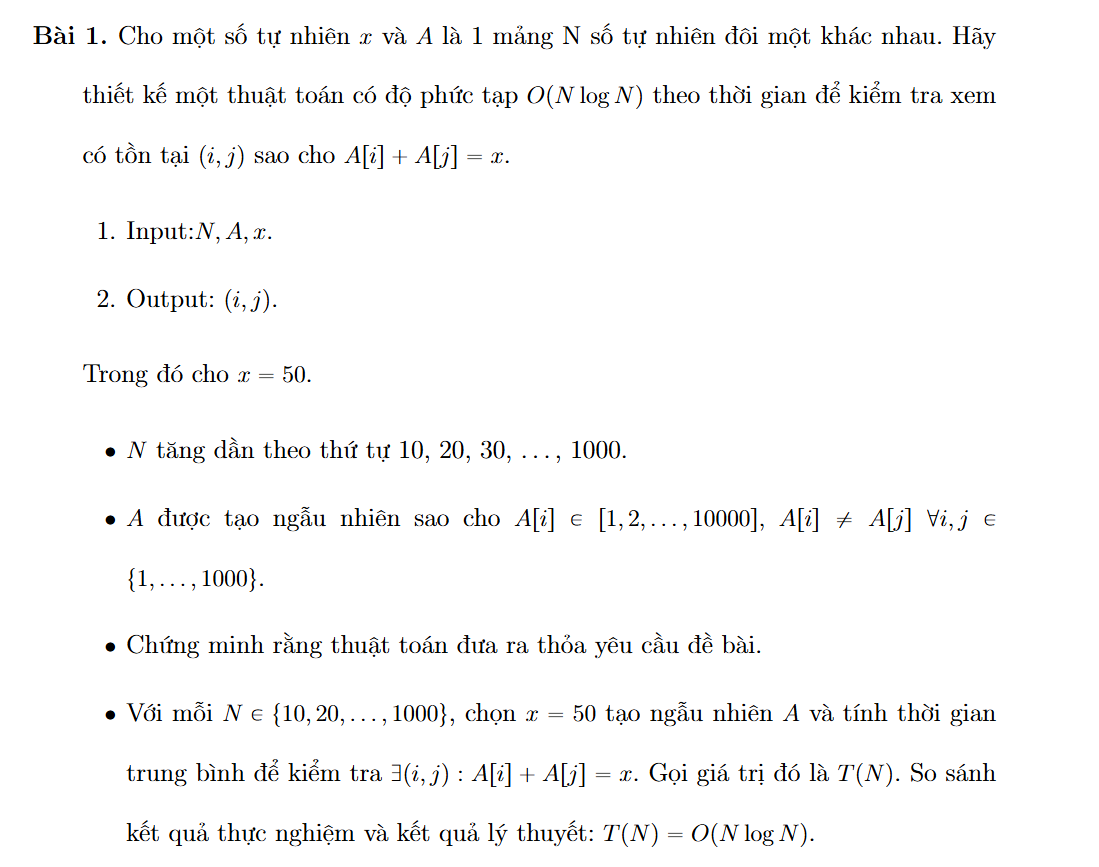

```python
import time
import numpy as np
import matplotlib.pyplot as plt

def quick_sort(arr):
    if len(arr) <= 1:
        return arr

    pivot_val = arr[len(arr) // 2][0]
    left = [x for x in arr if x[0] < pivot_val]
    middle = [x for x in arr if x[0] == pivot_val]
    right = [x for x in arr if x[0] > pivot_val]

    return quick_sort(left) + middle + quick_sort(right)
def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left_half = merge_sort(arr[:mid])
    right_half = merge_sort(arr[mid:])

    return merge(left_half, right_half)
def merge(left, right):
    result = []
    i = j = 0

    while i < len(left) and j < len(right):
        if left[i][0] < right[j][0]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])
    
    return result
def algorithm(N, A, x, method = 1):
    A_indexed = [(A[i], i) for i in range(N)]
    
    if method == 1:
        sorted_A = quick_sort(A_indexed)
    else:
        sorted_A = merge_sort(A_indexed)

    left, right = 0, N - 1
    
    while left < right:
        current_sum = sorted_A[left][0] + sorted_A[right][0]       
        if current_sum == x:
            return (sorted_A[left][1], sorted_A[right][1])
        elif current_sum < x:
            left += 1
        else:
            right -= 1
    return None


def calc_time(N, x, t=100, method=1):
    total_time = 0
    for _ in range(t):
        A = np.random.choice(np.arange(1, 10001), size=N, replace=False)
        
        start_time = time.perf_counter()
        algorithm(N, A, x, method=method)
        end_time = time.perf_counter()
        
        total_time += (end_time - start_time)
        
    return total_time / t

def test():
    x = 50
    N = np.arange(10, 1001, 10)
    
    plt.figure(figsize=(10, 6))
    colors = {1: 'blue', 2: 'green'}
    labels = {1: 'Quick Sort', 2: 'Merge Sort'}
    
    plot_time = [calc_time(n, x, t=5, method=1) for n in N]
    c = plot_time[-1] / (N[-1] * np.log(N[-1]))
    nlogn_time = c * N * np.log(N)
    plt.plot(N, nlogn_time, linestyle='--', color='red', label=r'$O(N \log N)$')

    for method in [1, 2]:
        test_times = []
        print(f"\nRunning {labels[method]}")
        for n in N:
            avg_time = calc_time(n, x, t=100, method=method)
            test_times.append(avg_time)
            # print(f"N = {n}, avg_time: {avg_time:.8f}")
            
        plt.plot(N, test_times, marker='o', markersize=3, color=colors[method], label=f'Thực nghiệm ({labels[method]})')

    plt.title('Quick Sort & Merge Sort vs O(N log N)')
    plt.xlabel('N')
    plt.ylabel('time (s)')
    plt.legend()
    plt.show()
test()
```
Note: quick sort và merge sort là các thuật toán sắp xếp có độ phức tạp trung bình O(N log N) đã học ở DSA nên sẽ không giải thích thêm.


Do bài toán yêu cầu tìm cặp phần tử (i,j) sao cho A[i] + A[j] = x vì vậy ta bắt buộc phải sắp xếp mảng và gán lại chỉ số như trong A_indexed để mà khi tìm cặp i, j thỏa mãn thì ta có thể trả về đúng vị trí ban đầu của chúng trong mảng A.

```python
A_indexed = [(A[i], i) for i in range(N)]

A = [3, 47, 10]
A_indexed = [(3,0), (47,1), (10,2)]
sorted_A = [(3,0), (10,2), (47,1)]
```

Ở đây, chúng ta sẽ sắp xếp mảng A theo 2 cách khác nhau là quick sort và merge sort
```python
if method == 1:
    sorted_A = quick_sort(A_indexed)
else:
    sorted_A = merge_sort(A_indexed)
```

Ý tưởng là sau khi sắp xếp, ta sẽ có một mảng sorted_A chứa các phần tử của A cùng với chỉ số ban đầu của chúng. Khi sử dụng thuật toán 2 con trỏ (left và right) để tìm cặp phần tử có tổng bằng x, ta sẽ truy cập vào sorted_A[left][0] và sorted_A[right][0] để tính tổng, ta có các trường hợp sau:
- Nếu tổng bằng x, ta trả về chỉ số ban đầu của hai phần tử đó là sorted_A[left][1] và sorted_A[right][1].
- Nếu tổng nhỏ hơn x, ta di chuyển con trỏ left sang phải để tăng tổng.
- Nếu tổng lớn hơn x, ta di chuyển con trỏ right sang trái để giảm tổng.

Ta lặp lại quá trình này cho đến khi tìm được cặp phần tử thỏa mãn hoặc left >= right, khi đó ta kết luận không tồn tại cặp phần tử nào có tổng bằng x.

```python
    left, right = 0, N - 1
    
    while left < right:
        current_sum = sorted_A[left][0] + sorted_A[right][0]       
        if current_sum == x:
            return (sorted_A[left][1], sorted_A[right][1])
        elif current_sum < x:
            left += 1
        else:
            right -= 1
    return None

# vd
sorted_A = [3, 10, 20, 30, 47]   (x = 55)
Bước 1: 3  + 47 = 50 < 55 -> left++
Bước 2: 10 + 47 = 57 > 55 -> right--
Bước 3: 10 + 30 = 40 < 55 -> left++
Bước 4: 20 + 30 = 50 < 55 -> left++
left >= right -> không tìm thấy (None)
```

Do đề bài yêu cầu so sánh thời gian thực nghiệm với lý thuyết O(N log N) nên ta sẽ vẽ đồ thị thời gian thực nghiệm của quick sort và merge sort cùng với đường biểu diễn O(N log N) để so sánh.

```python 
plot_time = [calc_time(n, x, t=5, method=1) for n in N]
c = plot_time[-1] / (N[-1] * np.log(N[-1]))
nlogn_time = c * N * np.log(N)
plt.plot(N, nlogn_time, linestyle='--', color='red', label=r'$O(N \log N)$')
```

Ở đây, chúng ta tính thời gian thực nghiệm của quick sort cho một số giá trị N nhất định và sử dụng giá trị thời gian cuối cùng để ước lượng hằng số c trong công thức O(N log N). Sau đó, chúng ta vẽ đường biểu diễn O(N log N) trên cùng đồ thị với thời gian thực nghiệm của quick sort và merge sort để so sánh.

```python 
for method in [1, 2]:
    test_times = []
    print(f"\nRunning {labels[method]}")
    for n in N:
        avg_time = calc_time(n, x, t=100, method=method)
        test_times.append(avg_time)
        # print(f"N = {n}, avg_time: {avg_time:.8f}")
        
    plt.plot(N, test_times, marker='o', markersize=3, color=colors[method], label=f'Thực nghiệm ({labels[method]})')
```

Do đề bài yêu cầu ta phải so sánh thời gian thực nghiệm trung bình nên ta phải làm hàm calc_time chạy nhiều lần (t=100) để lấy thời gian trung bình cho mỗi giá trị N.

```python
def calc_time(N, x, t=100, method=1):
    total_time = 0
    for _ in range(t):
        A = np.random.choice(np.arange(1, 10001), size=N, replace=False)
        
        start_time = time.perf_counter()
        algorithm(N, A, x, method=method)
        end_time = time.perf_counter()
        
        total_time += (end_time - start_time)
        
    return total_time / t
```
Kết quả thu được:

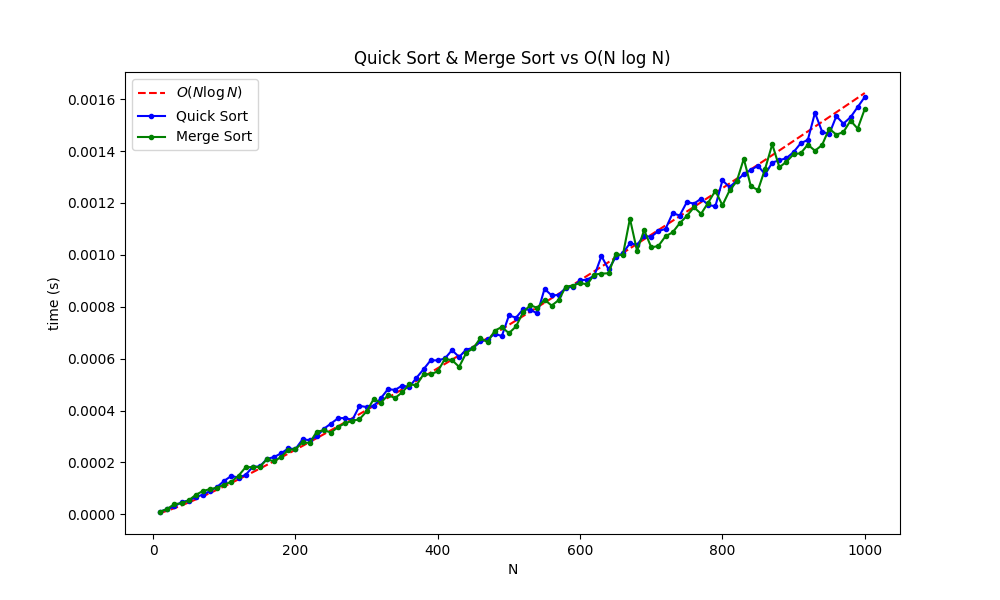

Về thục nghiệm, ta thấy rằng thời gian thực nghiệm của quick sort và merge sort đều có xu hướng tăng theo N và gần giống với đường biểu diễn O(N log N). 
Hơn nữa ta có thể chứng minh được rằng thuật toán của chúng ta có độ phức tạp O(N log N) như sau:
- Gọi T(N) là thời gian thực hiện thuật toán với đầu vào có kích thước N.
- Bước sắp xếp mảng A_indexed có độ phức tạp O(N log N) do sử dụng thuật toán sắp xếp quick sort hoặc merge sort.
- Bước tìm cặp phần tử có tổng bằng x sử dụng thuật toán 2 con trỏ có độ phức tạp O(N)
 Như vậy T(N) = O(N log N) + O(N) = O(N log N) do O(max(N log N, N)) = O(N log N).

### Bài tập 2:
**Câu hỏi**:

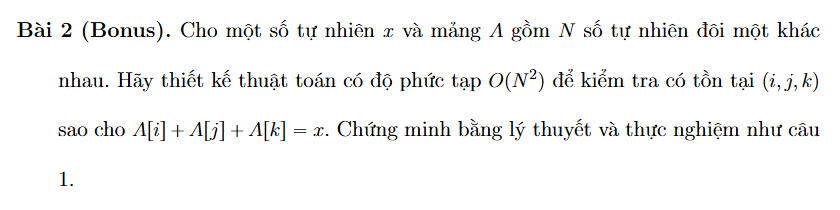


```python
import time
import numpy as np
import matplotlib.pyplot as plt

def quick_sort(arr):
    if len(arr) <= 1:
        return arr

    pivot_val = arr[len(arr) // 2][0]
    left = [x for x in arr if x[0] < pivot_val]
    middle = [x for x in arr if x[0] == pivot_val]
    right = [x for x in arr if x[0] > pivot_val]

    return quick_sort(left) + middle + quick_sort(right)

def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left_half = merge_sort(arr[:mid])
    right_half = merge_sort(arr[mid:])

    return merge(left_half, right_half)

def merge(left, right):
    result = []
    i = j = 0

    while i < len(left) and j < len(right):
        if left[i][0] < right[j][0]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])
    
    return result


def algorithm(N, A, x, method=1):
    A_indexed = [(A[i], i) for i in range(N)]
    
    if method == 1:
        sorted_A = quick_sort(A_indexed)
    else:
        sorted_A = merge_sort(A_indexed)


    for i in range(N - 2):
        target = x - sorted_A[i][0]
        
        left, right = i + 1, N - 1
        
        while left < right:
            current_sum = sorted_A[left][0] + sorted_A[right][0]       
            if current_sum == target:
                return (sorted_A[i][1], sorted_A[left][1], sorted_A[right][1])
            elif current_sum < target:
                left += 1
            else:
                right -= 1
                
    return None

def calc_time(N, x, t=100, method=1):
    total_time = 0
    for _ in range(t):
        A = np.random.choice(np.arange(1, 10001), size=N, replace=False)
        
        start_time = time.perf_counter()
        algorithm(N, A, x, method=method)
        end_time = time.perf_counter()
        
        total_time += (end_time - start_time)
        
    return total_time / t

def test():
    x = 50
    N = np.arange(10, 1001, 20) 
    
    plt.figure(figsize=(10, 6))
    colors = {1: 'blue', 2: 'green'}
    labels = {1: 'Quick Sort', 2: 'Merge Sort'}
    

    plot_time = [calc_time(n, x, t=100, method=1) for n in N]
    c = plot_time[-1] / (N[-1]**2)
    n2_time = c * (N**2)
    
    plt.plot(N, n2_time, linestyle='--', color='red', label=r'$O(N^2)$')

    for method in [1, 2]:
        test_times = []
        print(f"\nRunning {labels[method]} ...")
        for n in N:
            avg_time = calc_time(n, x, t=100, method=method)
            test_times.append(avg_time)
            
        plt.plot(N, test_times, marker='o', markersize=3, color=colors[method], label=f'{labels[method]}')

    plt.title('Quick Sort & Merge Sort vs O(N^2)')
    plt.xlabel('N')
    plt.ylabel('time (s)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
test()
```

Cũng như bài tập 1, chúng ta sử dụng mảng có chỉ số để lưu trữ giá trị và vị trí ban đầu của phần tử trong mảng A. Tức ta sẽ trả về (i, j, k) thay vì (i, j) như bài tập 1.

```python
A_indexed = [(A[i], i) for i in range(N)]
```

Do đề bài yêu cầu tìm bộ ba phần tử (i, j, k) sao cho A[i] + A[j] + A[k] = x vì vậy ta bắt buộc phải sắp xếp mảng và gán lại chỉ số như trong A_indexed để mà khi tìm được bộ ba i, j, k thỏa mãn thì ta có thể trả về đúng vị trí ban đầu của chúng trong mảng A.

```python
if method == 1:
    sorted_A = quick_sort(A_indexed)
else:
    sorted_A = merge_sort(A_indexed)
```

Ý tưởng là sau khi sắp xếp, ta sẽ có một mảng sorted_A chứa các phần tử của A cùng với chỉ số ban đầu của chúng. Khi sử dụng thuật toán 2 con trỏ (left và right) để tìm cặp phần tử có tổng bằng target = x - sorted_A[i][0], ta sẽ truy cập vào sorted_A[left][0] và sorted_A[right][0] để tính tổng, ta có các trường hợp sau:
- Nếu tổng bằng target, ta trả về chỉ số ban đầu của ba phần tử đó là sorted_A[i][1], sorted_A[left][1], sorted_A[right][1].
- Nếu tổng nhỏ hơn target, ta di chuyển con trỏ left sang phải để tăng tổng.
- Nếu tổng lớn hơn target, ta di chuyển con trỏ right sang trái để giảm tổng. Ta lặp lại quá trình này cho đến khi tìm được cặp phần tử thỏa mãn. Nếu không tìm được cặp phần tử nào có tổng bằng target thì ta tiếp tục với i tiếp theo. Nếu sau khi duyệt hết i mà vẫn không tìm được bộ ba phần tử nào có tổng bằng x thì ta trả về None.

```python
    for i in range(N - 2):
        target = x - sorted_A[i][0]
        
        left, right = i + 1, N - 1
        
        while left < right:
            current_sum = sorted_A[left][0] + sorted_A[right][0]       
            if current_sum == target:
                return (sorted_A[i][1], sorted_A[left][1], sorted_A[right][1])
            elif current_sum < target:
                left += 1
            else:
                right -= 1
                
    return None
```

Do đề bài yêu cầu so sánh thời gian thực nghiệm với lý thuyết O(N^2) nên ta sẽ vẽ đồ thị thời gian thực nghiệm của quick sort và merge sort cùng với đường biểu diễn O(N^2) để so sánh.

```python
plot_time = [calc_time(n, x, t=100, method=1) for n in N]
c = plot_time[-1] / (N[-1]**2)
n2_time = c * (N**2)
plt.plot(N, n2_time, linestyle='--', color='red', label=r'$O(N^2)$')
```

Sau đó tính thoi gian thực nghiệm của quick sort và merge sort cho một số giá trị N nhất định và vẽ đường biểu diễn thời gian thực nghiệm trên cùng đồ thị với đường biểu diễn O(N^2) để so sánh.

```python
for method in [1, 2]:
    test_times = []
    print(f"\nRunning {labels[method]} ...")
    for n in N:
        avg_time = calc_time(n, x, t=100, method=method)
        test_times.append(avg_time)
        
    plt.plot(N, test_times, marker='o', markersize=3, color=colors[method], label=f'{labels[method]}')
```
Kết quả thu được:

![alt text](Figure_3.svg)

Về thục nghiệm, ta thấy rằng thời gian thực nghiệm của quick sort và merge sort đều có xu hướng tăng theo N, khá giống với đường biểu diễn O(N^2) (Nhưng mà không hoàn toàn trùng khớp vì do phần cứng và các yếu tố khác...).

Hơn nữa ta có thể chứng minh được rằng thuật toán của chúng ta có độ phức tạp O(N^2) như sau:
- Gọi T(N) là thời gian thực hiện thuật toán với đầu vào có kích thước N.
- Bước sắp xếp mảng A_indexed có độ phức tạp O(N log N) do sử dụng thuật toán sắp xếp quick sort hoặc merge sort.
- Bước tìm bộ ba phần tử có tổng bằng x sử dụng thuật toán 2 con trỏ có độ phức tạp O(N^2) do có 1 vòng lặp chạy từ (0, N-2) lần và trong mỗi lần lặp lại có thuật toán 2 con trỏ chạy tối đa N lần (while). Như vậy T(N) = O(N log N) + O(N^2) = O(N^2) do O(max(N log N, N^2)) = O(N^2).


